# **DETECTRON 2 + INPAINTING**

As I showed in the previous notebooks, Detectron 2 allows us to easily detect objects in images and generate masks for them. On the other hand, the inpainting process allows us to change the content of an image by filling in the masked areas with new content. By combining these two techniques, we can create a powerful tool for editing images in a more intuitive way.

In this notebook, I will create a simple pipeline that uses Detectron 2 to detect objects in an image, generates masks for those objects, and then applies inpainting to fill in the masked areas with new content based on a given prompt.

## **SETUP AND CONFIGURATION**

Configuration of Detectron 2

In [1]:
!python -m pip install pyyaml==5.1
import sys, os, distutils.core

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 274.2/274.2 kB 7.2 MB/s eta 0:00:00a 0:00:01
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [2]:
!git clone 'https://github.com/facebookresearch/detectron2'
dist = distutils.core.run_setup("./detectron2/setup.py")
!python -m pip install {' '.join([f"'{x}'" for x in dist.install_requires])}
sys.path.insert(0, os.path.abspath('./detectron2'))

Cloning into 'detectron2'...
remote: Enumerating objects: 15962, done.
remote: Counting objects: 100% (20/20), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 15962 (delta 8), reused 2 (delta 2), pack-reused 15942 (from 2)
Receiving objects: 100% (15962/15962), 6.71 MiB | 23.44 MiB/s, done.
Resolving deltas: 100% (11344/11344), done.
Ignoring dataclasses: markers 'python_version < "3.7"' don't match your environment
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.9/91.9 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 59.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.8/269.8 kB 30.3 MB/s eta 0:00:00
  Created wheel for fvcore: filename=fvc

In [3]:
import torch, detectron2
from detectron2.utils.logger import setup_logger
setup_logger()

<Logger detectron2 (DEBUG)>

In [4]:
import numpy as np
import os, json, cv2, random

from detectron2 import model_zoo
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg

In [5]:
cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"))
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5

In [6]:
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml")
predictor = DefaultPredictor(cfg)

[05/03 01:41:00 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from https://dl.fbaipublicfiles.com/detectron2/COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x/137849600/model_final_f10217.pkl ...


model_final_f10217.pkl: 178MB [00:00, 277MB/s]                            


In [ ]:
url = 'https://images.unsplash.com/photo-1520607162513-77705c0f0d4a?q=80&w=1200&auto=format&fit=crop'

In [19]:
import requests
from PIL import Image
from io import BytesIO
 
def download_image(url):
    response = requests.get(url)
    return Image.open(BytesIO(response.content)).convert("RGB")

Configuration of the inpainting model.

In [8]:
!pip install -qq -U diffusers transformers ftfy accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 76.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 136.9 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 509.1/509.1 kB 48.2 MB/s eta 0:00:00


In [9]:
from huggingface_hub import notebook_login

notebook_login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


In [10]:
from diffusers import StableDiffusionInpaintPipeline

device = "cuda"
model_path = "runwayml/stable-diffusion-inpainting"

pipe = StableDiffusionInpaintPipeline.from_pretrained(
    model_path,
    torch_dtype=torch.float16,
).to(device)

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


model_index.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

In [71]:
def segment(Image):
    image = download_image(Image)
    img = np.array(image)
    outputs = predictor(img)
    return outputs["instances"].pred_masks

In [72]:
guidance_scale=7.5
num_samples = 3
generator = torch.Generator(device="cuda").manual_seed(42)

def inpainting(image, mask_tensor, prompt):
    mask = mask_tensor.cpu().numpy()
    mask = (mask * 255).astype(np.uint8)
    mask_pil = Image.fromarray(mask, mode = 'L').resize((512, 512))

    output = pipe(
        prompt=prompt,
        image=image,
        mask_image=mask_pil,
        guidance_scale=guidance_scale,
        generator=generator,
        num_images_per_prompt=num_samples,
    ).images
    return output

In [73]:
import math
import matplotlib.pyplot as plt

In [74]:
def draw_grid(masks):
    segments = []
    for i in range(len(masks)):
        mask_tensor = masks[i]
        mask = mask_tensor.cpu().numpy()
        mask = (mask * 255).astype(np.uint8)         
        mask_pil = Image.fromarray(mask, mode="L")
        segments.append(mask_pil)
    
    cols = math.ceil(math.sqrt(len(segments))) 
    rows = math.ceil(len(segments) / cols)
    plt.figure(figsize=(cols * 3, rows * 3))

    for i, image in enumerate(segments):
        plt.subplot(rows, cols, i + 1)
        plt.title(f'Mask #{i+1}')
        plt.imshow(image, cmap="gray")
        plt.xticks([])
        plt.yticks([])

    plt.tight_layout()
    plt.show()

In [75]:
def inpainting_pipeline():
    img_url = input(str('Enter your url: '))
    image = download_image(img_url).resize((512, 512))
    seg = segment(img_url)
    draw_grid(seg)

    n = input('Enter the mask number to do inpainting: ')
    prompt = input(str('Now, enter the prompt to the inpainting model: '))
    output = inpainting(
        image= image,
        mask_tensor= seg[int(n)-1],
        prompt= prompt   
    )

    return output[0]



/tmp/ipykernel_7951/1346076245.py:7: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask_pil = Image.fromarray(mask, mode="L")


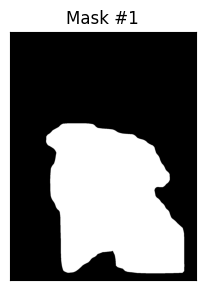

/tmp/ipykernel_7951/1995189933.py:8: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask_pil = Image.fromarray(mask, mode = 'L').resize((512, 512))


  0%|          | 0/50 [00:00<?, ?it/s]

In [97]:
img = inpainting_pipeline()

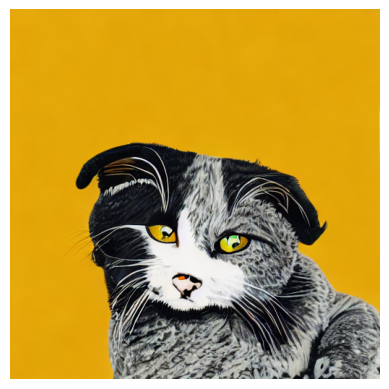

In [98]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.axis("off")
plt.show()